# PCA & Clustering Assignment 



## Step 0: Import Libraries


In [28]:
#  Standard Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


## Task 1: Exploratory Data Analysis (EDA)

### 1.1 — Load the Dataset

In [29]:
# Load the dataset
df = pd.read_csv('wine.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (178, 14)

First 5 rows:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [30]:
# Check data types and missing values
print("DATA TYPES")
print(df.dtypes)
print("MISSING VALUES")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

DATA TYPES
Type                 int64
Alcohol            float64
Malic              float64
Ash                float64
Alcalinity         float64
Magnesium            int64
Phenols            float64
Flavanoids         float64
Nonflavanoids      float64
Proanthocyanins    float64
Color              float64
Hue                float64
Dilution           float64
Proline              int64
dtype: object
MISSING VALUES
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

Total missing values: 0


## Observation: The dataset has no missing values — no data cleaning required.

In [31]:
# Statistical summary of all features
print("STATISTICAL SUMMARY")
df.describe().round(2)

STATISTICAL SUMMARY


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,1.94,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.78,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,1.00,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,1.00,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,2.00,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,3.00,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,3.00,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


Wine Type Distribution:
Type
2    71
1    59
3    48
Name: count, dtype: int64


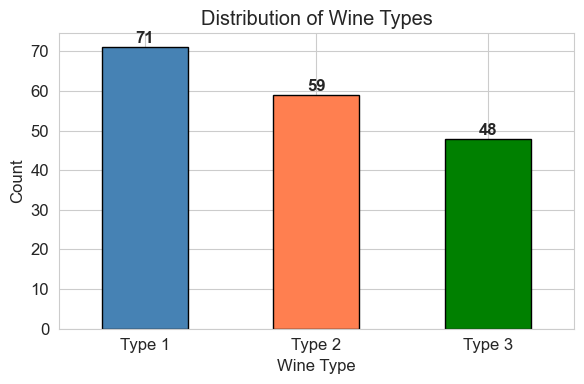

The dataset has 3 wine types: 59 samples of Type 1, 71 of Type 2, 48 of Type 3.


In [32]:
# Distribution of the target class (Type)
print("Wine Type Distribution:")
print(df['Type'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['Type'].value_counts().plot(kind='bar', color=['steelblue','coral','green'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Wine Types')
ax.set_xlabel('Wine Type')
ax.set_ylabel('Count')
ax.set_xticklabels(['Type 1', 'Type 2', 'Type 3'], rotation=0)
for i, v in enumerate(df['Type'].value_counts()):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("The dataset has 3 wine types: 59 samples of Type 1, 71 of Type 2, 48 of Type 3.")

### 1.2  Feature Distributions (Histograms)


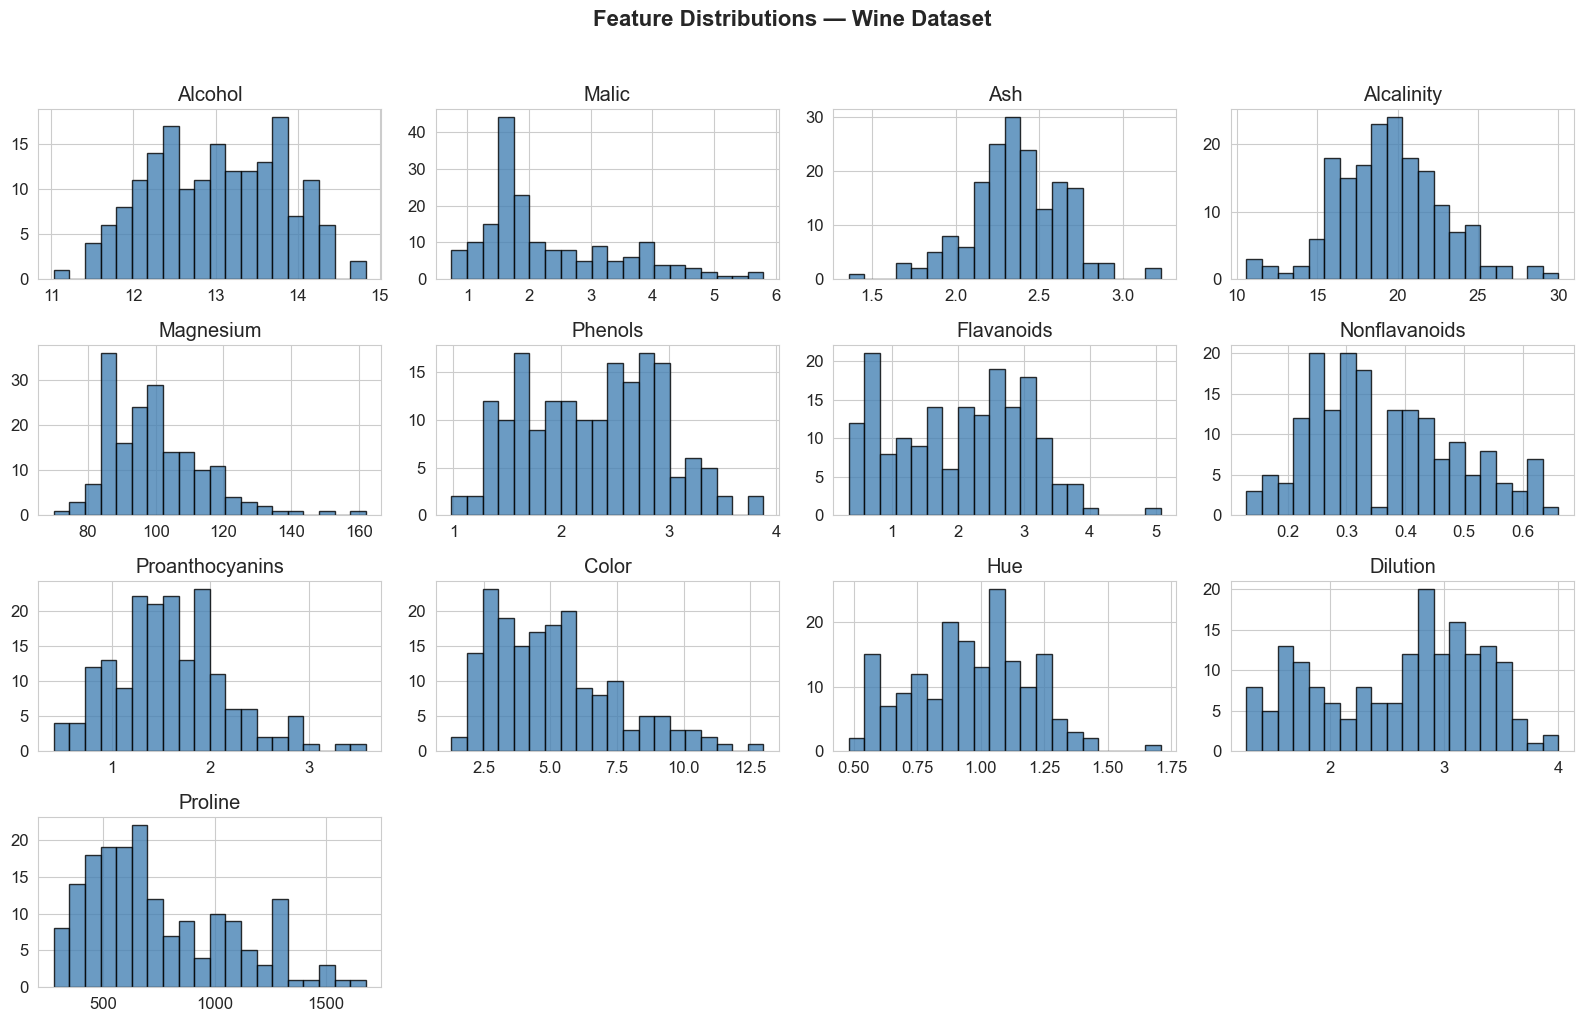


    Key Observations:
  - Features like Alcohol, Phenols, Flavanoids appear roughly bell-shaped (normal).
  - Proline has a large range (278–1680), suggesting it needs standardization.
  - Malic acid is slightly right-skewed.
  - Features have very different scales → StandardScaler is essential before PCA.



In [33]:
# Histogram for all features
features = df.columns[1:]  # All except 'Type'

df[features].hist(bins=20, figsize=(16, 10), color='steelblue', edgecolor='black', alpha=0.8)
plt.suptitle('Feature Distributions — Wine Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
    Key Observations:
  - Features like Alcohol, Phenols, Flavanoids appear roughly bell-shaped (normal).
  - Proline has a large range (278–1680), suggesting it needs standardization.
  - Malic acid is slightly right-skewed.
  - Features have very different scales → StandardScaler is essential before PCA.
""")

### 1.3  Box Plots

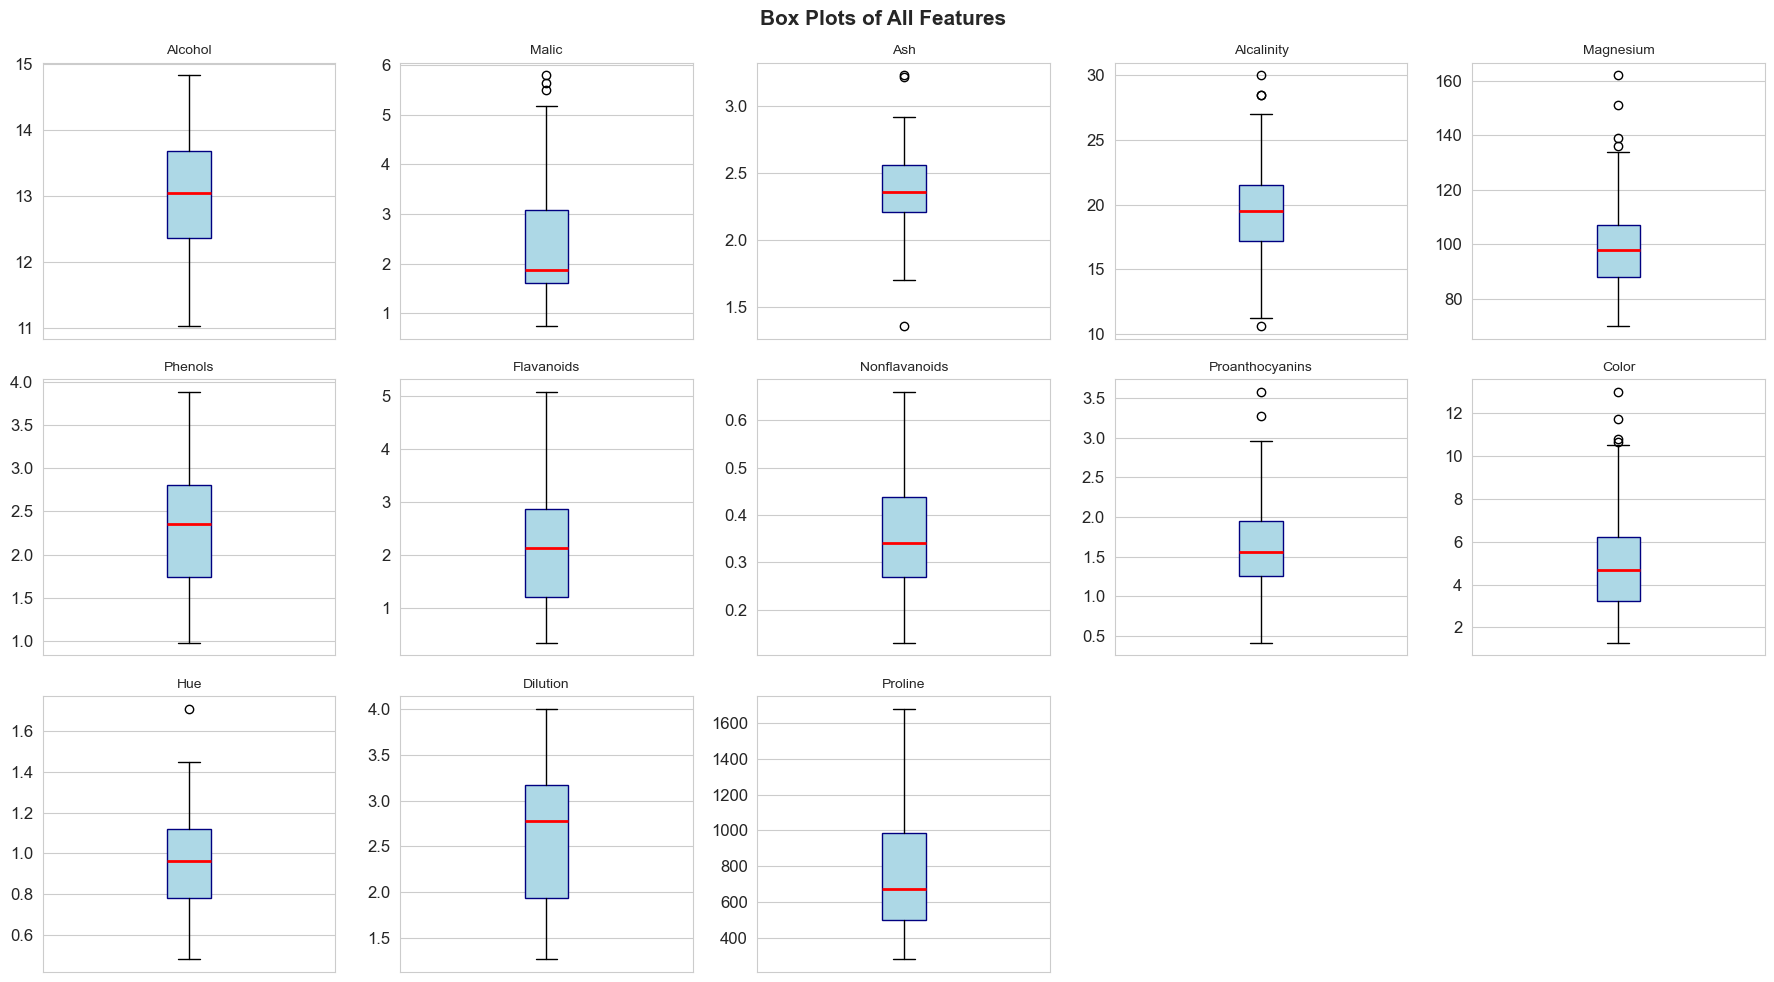


   Key Observations:
  - Proline has the largest scale, dominating if not standardized.
  - Magnesium, Malic, and Color show some outliers.
  - This confirms the need for StandardScaler before PCA.



In [34]:
# Box plots for all features
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# Hide unused subplots
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots of All Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
   Key Observations:
  - Proline has the largest scale, dominating if not standardized.
  - Magnesium, Malic, and Color show some outliers.
  - This confirms the need for StandardScaler before PCA.
""")

### 1.4  Correlation Heatmap


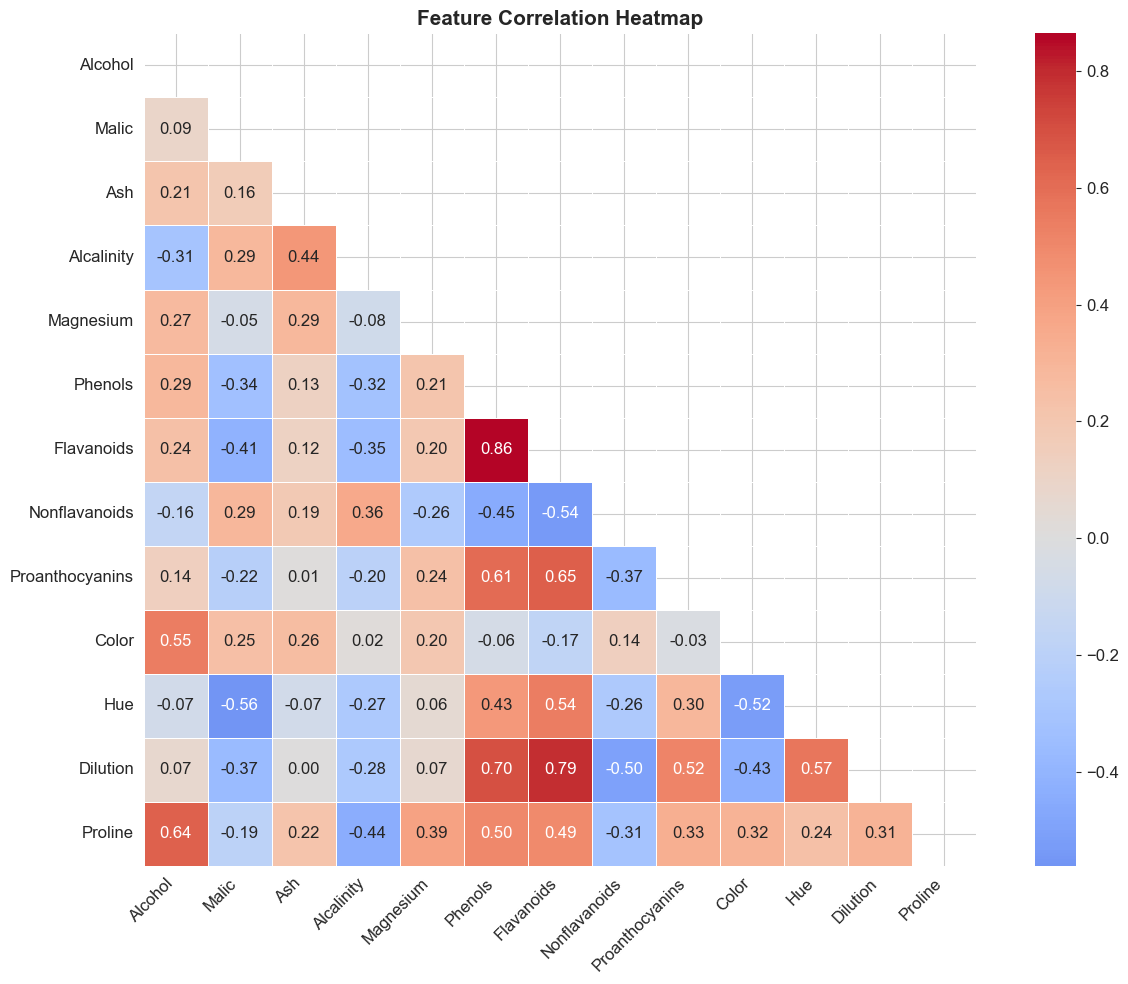

Top 10 Feature Correlations:
Phenols          Flavanoids    0.865
Dilution         Flavanoids    0.787
                 Phenols       0.700
Proanthocyanins  Flavanoids    0.653
Proline          Alcohol       0.644
Proanthocyanins  Phenols       0.612
Hue              Dilution      0.565
Malic            Hue           0.561
Color            Alcohol       0.546
Hue              Flavanoids    0.543
dtype: float64

   Key Observations:
  - Flavanoids & Phenols: strong positive correlation (~0.86)
  - Flavanoids & Dilution: strong positive correlation (~0.79)
  - Nonflavanoids is negatively correlated with Flavanoids
  - Multiple highly correlated features confirm PCA will be effective at compression.



In [35]:
# Correlation Heatmap
corr_matrix = df[features].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            mask=mask,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print top correlations
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print("Top 10 Feature Correlations:")
print(corr_pairs.head(10).round(3))

print("""
   Key Observations:
  - Flavanoids & Phenols: strong positive correlation (~0.86)
  - Flavanoids & Dilution: strong positive correlation (~0.79)
  - Nonflavanoids is negatively correlated with Flavanoids
  - Multiple highly correlated features confirm PCA will be effective at compression.
""")



## Task 2: Dimensionality Reduction with PCA

### 2.1 — Standardize the Features

In [36]:
# Separate features and target
X = df[features].values     # Feature matrix (178 × 13)
y = df['Type'].values       # True labels (for evaluation only)

# Standardize: mean = 0, std = 1 for each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify standardization
scaled_df = pd.DataFrame(X_scaled, columns=features)
print("After Standardization:")
print(f"  Mean of each feature (should be ~0): \n{scaled_df.mean().round(4)}")
print(f"  Std of each feature (should be ~1): \n{scaled_df.std().round(4)}")

After Standardization:
  Mean of each feature (should be ~0): 
Alcohol           -0.0
Malic             -0.0
Ash               -0.0
Alcalinity        -0.0
Magnesium         -0.0
Phenols            0.0
Flavanoids        -0.0
Nonflavanoids      0.0
Proanthocyanins   -0.0
Color              0.0
Hue                0.0
Dilution           0.0
Proline           -0.0
dtype: float64
  Std of each feature (should be ~1): 
Alcohol            1.0028
Malic              1.0028
Ash                1.0028
Alcalinity         1.0028
Magnesium          1.0028
Phenols            1.0028
Flavanoids         1.0028
Nonflavanoids      1.0028
Proanthocyanins    1.0028
Color              1.0028
Hue                1.0028
Dilution           1.0028
Proline            1.0028
dtype: float64


### 2.2  Apply PCA (Full — All Components)


In [37]:
# Apply PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance ratio for each component
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PC    | Variance Explained | Cumulative Variance")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    marker = " ← 95%" if abs(cv - 0.95) < 0.05 else ""
    print(f"PC{i+1:2d}  |    {ev*100:5.2f}%          |    {cv*100:5.2f}%{marker}")

PC    | Variance Explained | Cumulative Variance
PC 1  |    36.20%          |    36.20%
PC 2  |    19.21%          |    55.41%
PC 3  |    11.12%          |    66.53%
PC 4  |     7.07%          |    73.60%
PC 5  |     6.56%          |    80.16%
PC 6  |     4.94%          |    85.10%
PC 7  |     4.24%          |    89.34%
PC 8  |     2.68%          |    92.02% ← 95%
PC 9  |     2.22%          |    94.24% ← 95%
PC10  |     1.93%          |    96.17% ← 95%
PC11  |     1.74%          |    97.91% ← 95%
PC12  |     1.30%          |    99.20% ← 95%
PC13  |     0.80%          |    100.00%


### 2.3  Scree Plot & Cumulative Explained Variance


AttributeError: 'Axes' object has no attribute 'set_xlbel'

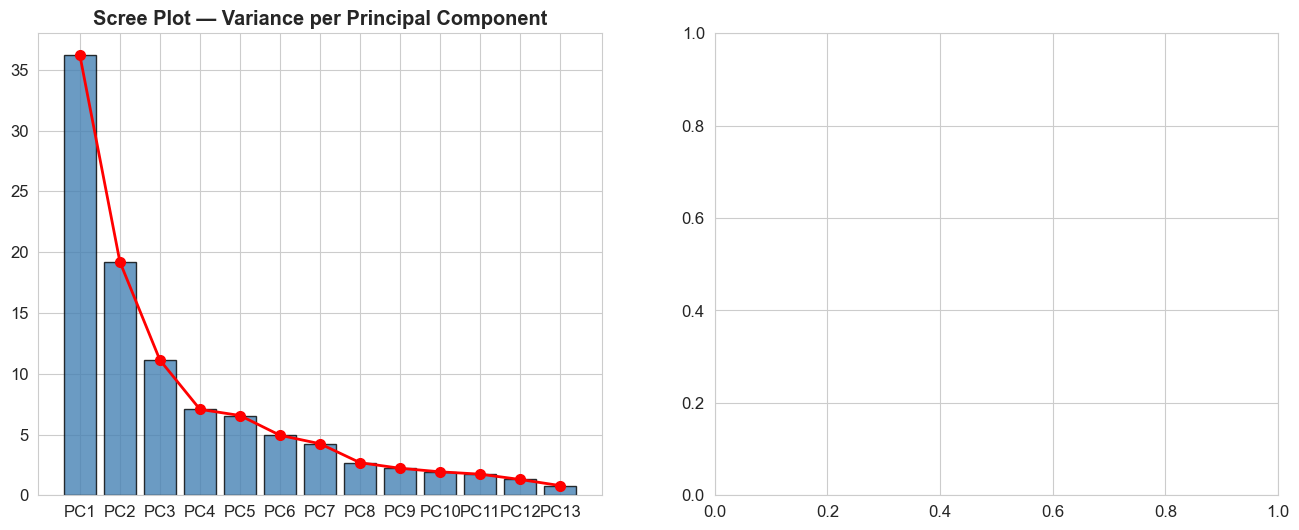

In [38]:
n_components_all = len(explained_variance)
component_labels = [f'PC{i+1}' for i in range(n_components_all)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Scree Plot ──────────────────────────────────────────────────
ax1.bar(component_labels, explained_variance * 100, color='steelblue', edgecolor='black', alpha=0.8)
ax1.plot(component_labels, explained_variance * 100, 'ro-', markersize=7, linewidth=2)
ax1.set_title('Scree Plot — Variance per Principal Component', fontweight='bold')
ax1.set_xlbel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_xticklabels(component_labels, rotation=45)

# ── Cumulative Variance Plot ────────────────────────────────────
ax2.plot(component_labels, cumulative_variance * 100, 'bo-', markersize=8, linewidth=2)
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.axhline(y=99, color='orange', linestyle='--', linewidth=2, label='99% Threshold')
ax2.fill_between(range(n_components_all), cumulative_variance * 100, alpha=0.2, color='blue')
ax2.set_title('Cumulative Explained Variance', fontweight='bold')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_xticks(range(n_components_all))
ax2.set_xticklabels(component_labels, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.4)

# Mark where 95% is reached
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
ax2.axvline(x=n_95-1, color='red', linestyle=':', linewidth=1.5)
ax2.annotate(f'{n_95} PCs\n= 95%', xy=(n_95-1, 95), xytext=(n_95+0.5, 85),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"""
    Key Findings:
  - PC1 alone explains {explained_variance[0]*100:.1f}% of the variance.
  - PC1 + PC2 explain {cumulative_variance[1]*100:.1f}% (great for 2D visualization!)
  - {n_95} components are needed to retain 95% of the total variance.
  - Original: 13 features → Reduced: {n_95} components (saves {(1 - n_95/13)*100:.0f}% space with only 5% info loss).
""")

### 2.4 Apply PCA with Optimal Number of Components

In [ ]:
# Use components that explain 95% of variance
n_components_optimal = n_95  # From above analysis

pca = PCA(n_components=n_components_optimal)
X_pca = pca.fit_transform(X_scaled)

print(f" PCA Applied:")
print(f"   Original dimensions : {X_scaled.shape}")
print(f"   Reduced dimensions  : {X_pca.shape}")
print(f"   Variance retained   : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   Information loss    : {(1 - pca.explained_variance_ratio_.sum())*100:.2f}%")

# Show PCA component matrix (loadings)
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)],
    index=features
)
print("\nPCA Loadings (contribution of each feature to each PC):")
pca_loadings.round(3)

In [ ]:
# Visualize PCA Loading Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(pca_loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Loading Value'})
plt.title('PCA Loadings Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.show()

print("""
   How to Read Loadings:
  - High positive value: feature strongly pushes PC in positive direction
  - High negative value: feature strongly pushes PC in negative direction
  - Near zero: feature contributes little to that PC
""")

### 2.5  2D PCA Visualization

Plotting the first two principal components gives us a 2D view of the data. This is extremely useful to check if wine types form **natural clusters**.

In [ ]:
# 2D PCA scatter plot colored by true wine type
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

colors = {1: 'crimson', 2: 'royalblue', 3: 'forestgreen'}
plt.figure(figsize=(10, 7))

for wine_type in [1, 2, 3]:
    mask = y == wine_type
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors[wine_type], label=f'Type {wine_type}',
                s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=13)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=13)
plt.title('2D PCA Projection — Colored by True Wine Type', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
    PCA Visualization Insights:
  - PC1 + PC2 together capture {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of variance.
  - The 3 wine types are largely separable even in 2D PCA space!
  - This confirms that PCA preserves the discriminative structure of the data.
""")


##  Task 3: Clustering on Original (Scaled) Data


### 3.1 — Find Optimal K using Elbow Method

In [ ]:
# Elbow Method — Inertia (WCSS)
# Inertia = sum of squared distances of samples to their nearest cluster center

inertia_original = []
silhouette_original = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_original.append(km.inertia_)
    silhouette_original.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Plot
ax1.plot(k_range, inertia_original, 'bo-', markersize=8, linewidth=2)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=2, label='K=3 (elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method — Original Data', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_original, 'rs-', markersize=8, linewidth=2)
ax2.axvline(x=3, color='blue', linestyle='--', linewidth=2, label='K=3 (best)')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score — Original Data', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(silhouette_original)]
print(f"Best K by Silhouette Score: {best_k_sil} (score = {max(silhouette_original):.4f})")
print("""
  The elbow at K=3 and highest silhouette at K=3 both confirm 3 clusters.
   This matches the 3 actual wine types in the dataset!
""")

### 3.2  Apply K-Means (K=3) on Original Data

In [ ]:
# Apply KMeans with K=3 on original scaled data
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

# Evaluation
sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig  = davies_bouldin_score(X_scaled, labels_orig)

print("=" * 50)
print("K-MEANS ON ORIGINAL DATA (K=3)")
print("=" * 50)
print(f"  Silhouette Score   : {sil_orig:.4f}  (higher is better, range: -1 to 1)")
print(f"  Davies-Bouldin Index: {db_orig:.4f}  (lower is better, min = 0)")
print(f"  Inertia (WCSS)     : {kmeans_orig.inertia_:.2f}")

# Cluster sizes
print("\nCluster Sizes:")
unique, counts = np.unique(labels_orig, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples")

### 3.3  Visualize K-Means Clusters on Original Data (2D PCA Projection)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap_clusters = plt.cm.get_cmap('Set1', 3)
colors_3 = ['#E41A1C', '#377EB8', '#4DAF4A']

#  Left: K-Means Clusters 
for cluster in range(3):
    mask = labels_orig == cluster
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors_3[cluster], label=f'Cluster {cluster}',
                    s=80, alpha=0.8, edgecolors='white')

# Plot centroids in PCA space
centroids_2d = pca_2d.transform(kmeans_orig.cluster_centers_)
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')

axes[0].set_title('K-Means Clusters (Original Data)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Right: True Labels (for comparison) 
for wine_type, color in zip([1, 2, 3], colors_3):
    mask = y == wine_type
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=f'True Type {wine_type}',
                    s=80, alpha=0.8, edgecolors='white')

axes[1].set_title('True Wine Types (Reference)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means on Original Data vs. True Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
   Visual Comparison:
  - K-Means successfully discovers 3 clusters that closely match the true wine types.
  - Some minor overlap exists at cluster boundaries, especially between Type 1 and Type 2.
  - The black X markers show cluster centroids — they are well-separated.
""")


##  Task 4: Clustering on PCA-Transformed Data

### 4.1 — Apply K-Means on PCA Data

In [ ]:
# Apply KMeans on PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

# Evaluation
sil_pca = silhouette_score(X_pca, labels_pca)
db_pca  = davies_bouldin_score(X_pca, labels_pca)


print("K-MEANS ON PCA DATA (K=3)")
print(f"  Silhouette Score   : {sil_pca:.4f}")
print(f"  Davies-Bouldin Index: {db_pca:.4f}")
print(f"  Inertia (WCSS)     : {kmeans_pca.inertia_:.2f}")

print("\nCluster Sizes:")
for cluster, count in zip(*np.unique(labels_pca, return_counts=True)):
    print(f"  Cluster {cluster}: {count} samples")

### 4.2 — Visualize K-Means on PCA Data

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Left: Clustering on PCA Data 
for cluster in range(3):
    mask = labels_pca == cluster
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors_3[cluster], label=f'Cluster {cluster}',
                    s=80, alpha=0.8, edgecolors='white')

axes[0].set_title('K-Means Clusters (PCA Data)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: True Labels ─────────────────────────────────────────
for wine_type, color in zip([1, 2, 3], colors_3):
    mask = y == wine_type
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=f'True Type {wine_type}',
                    s=80, alpha=0.8, edgecolors='white')

axes[1].set_title('True Wine Types (Reference)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means on PCA Data vs. True Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##  Task 5: Comparison & Analysis

### 5.1 — Side-by-Side Metric Comparison

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Silhouette Score ↑', 'Davies-Bouldin Index ↓', 'Inertia (WCSS) ↓',
               'Input Dimensions', 'Variance Used'],
    'Original Data': [
        f"{sil_orig:.4f}",
        f"{db_orig:.4f}",
        f"{kmeans_orig.inertia_:.2f}",
        "13",
        "100%"
    ],
    'PCA Data': [
        f"{sil_pca:.4f}",
        f"{db_pca:.4f}",
        f"{kmeans_pca.inertia_:.2f}",
        str(n_components_optimal),
        f"{pca.explained_variance_ratio_.sum()*100:.1f}%"
    ]
})


print("CLUSTERING PERFORMANCE COMPARISON")
print(comparison.to_string(index=False))
print("↑ = higher is better   |   ↓ = lower is better")

In [ ]:
# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Silhouette Score
bars1 = ax1.bar(['Original Data', 'PCA Data'], [sil_orig, sil_pca],
                color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
ax1.set_title('Silhouette Score Comparison\n(Higher = Better Clusters)', fontweight='bold')
ax1.set_ylabel('Silhouette Score')
ax1.set_ylim(0, max(sil_orig, sil_pca) * 1.2)
for bar, val in zip(bars1, [sil_orig, sil_pca]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

# Davies-Bouldin
bars2 = ax2.bar(['Original Data', 'PCA Data'], [db_orig, db_pca],
                color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
ax2.set_title('Davies-Bouldin Index Comparison\n(Lower = Better Clusters)', fontweight='bold')
ax2.set_ylabel('Davies-Bouldin Index')
ax2.set_ylim(0, max(db_orig, db_pca) * 1.2)
for bar, val in zip(bars2, [db_orig, db_pca]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Clustering Performance: Original vs PCA Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 — Discussion of Results

In [40]:
# Print detailed comparison insights
better_sil = "PCA Data" if sil_pca > sil_orig else "Original Data"
better_db  = "PCA Data" if db_pca < db_orig else "Original Data"


NameError: name 'sil_orig' is not defined

### 5.3 — Cluster Overlap Heatmap (Predicted vs True Labels)

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes, [labels_orig, labels_pca],
                              ['Original Data', 'PCA Data']):
    # Map cluster labels to best matching true labels
    from scipy.stats import mode
    mapped = np.zeros_like(labels)
    for cluster in range(3):
        mask = labels == cluster
        if mask.sum() > 0:
            mapped[mask] = mode(y[mask], keepdims=True)[0][0]
    
    cm = confusion_matrix(y, mapped)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Type 1', 'Type 2', 'Type 3'],
                yticklabels=['Type 1', 'Type 2', 'Type 3'],
                cbar=False)
    ax.set_title(f'Cluster vs True Label — {title}', fontweight='bold')
    ax.set_xlabel('Predicted Cluster')
    ax.set_ylabel('True Type')

plt.suptitle('Confusion Matrix: Predicted Clusters vs True Wine Types',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
   Reading the Confusion Matrix:
  - Diagonal values = correctly matched samples (high = good).
  - Off-diagonal = mismatches between K-Means cluster and true label.
  - Both methods show strong alignment with true wine types!
""")